In [9]:
# 3. Define the 8 DSOs
target_list = [
    {"name": "NGC6960", "label": "NGC6960 (Western Veil)"},
    {"name": "M27", "label": "M27 (Dumbbell Nebula)"},
    {"name": "NGC7635", "label": "NGC7635 (Bubble Nebula)"},
#    {"name": "M31", "label": "M31 (Andromeda Galaxy)"},
#    {"name": "M42", "label": "M42 (Orion Nebula)"},
    {"name": "M51", "label": "M51 (Whirlpool Galaxy)"},
#    {"name": "M13", "label": "M13 (Hercules Cluster)"},
    {"name": "M16", "label": "M16 (Eagle Nebula)"}
]

address = "Wiesenstrasse 58 64331 Weiterstadt Germany"

base_date = Time("2026-07-04") 


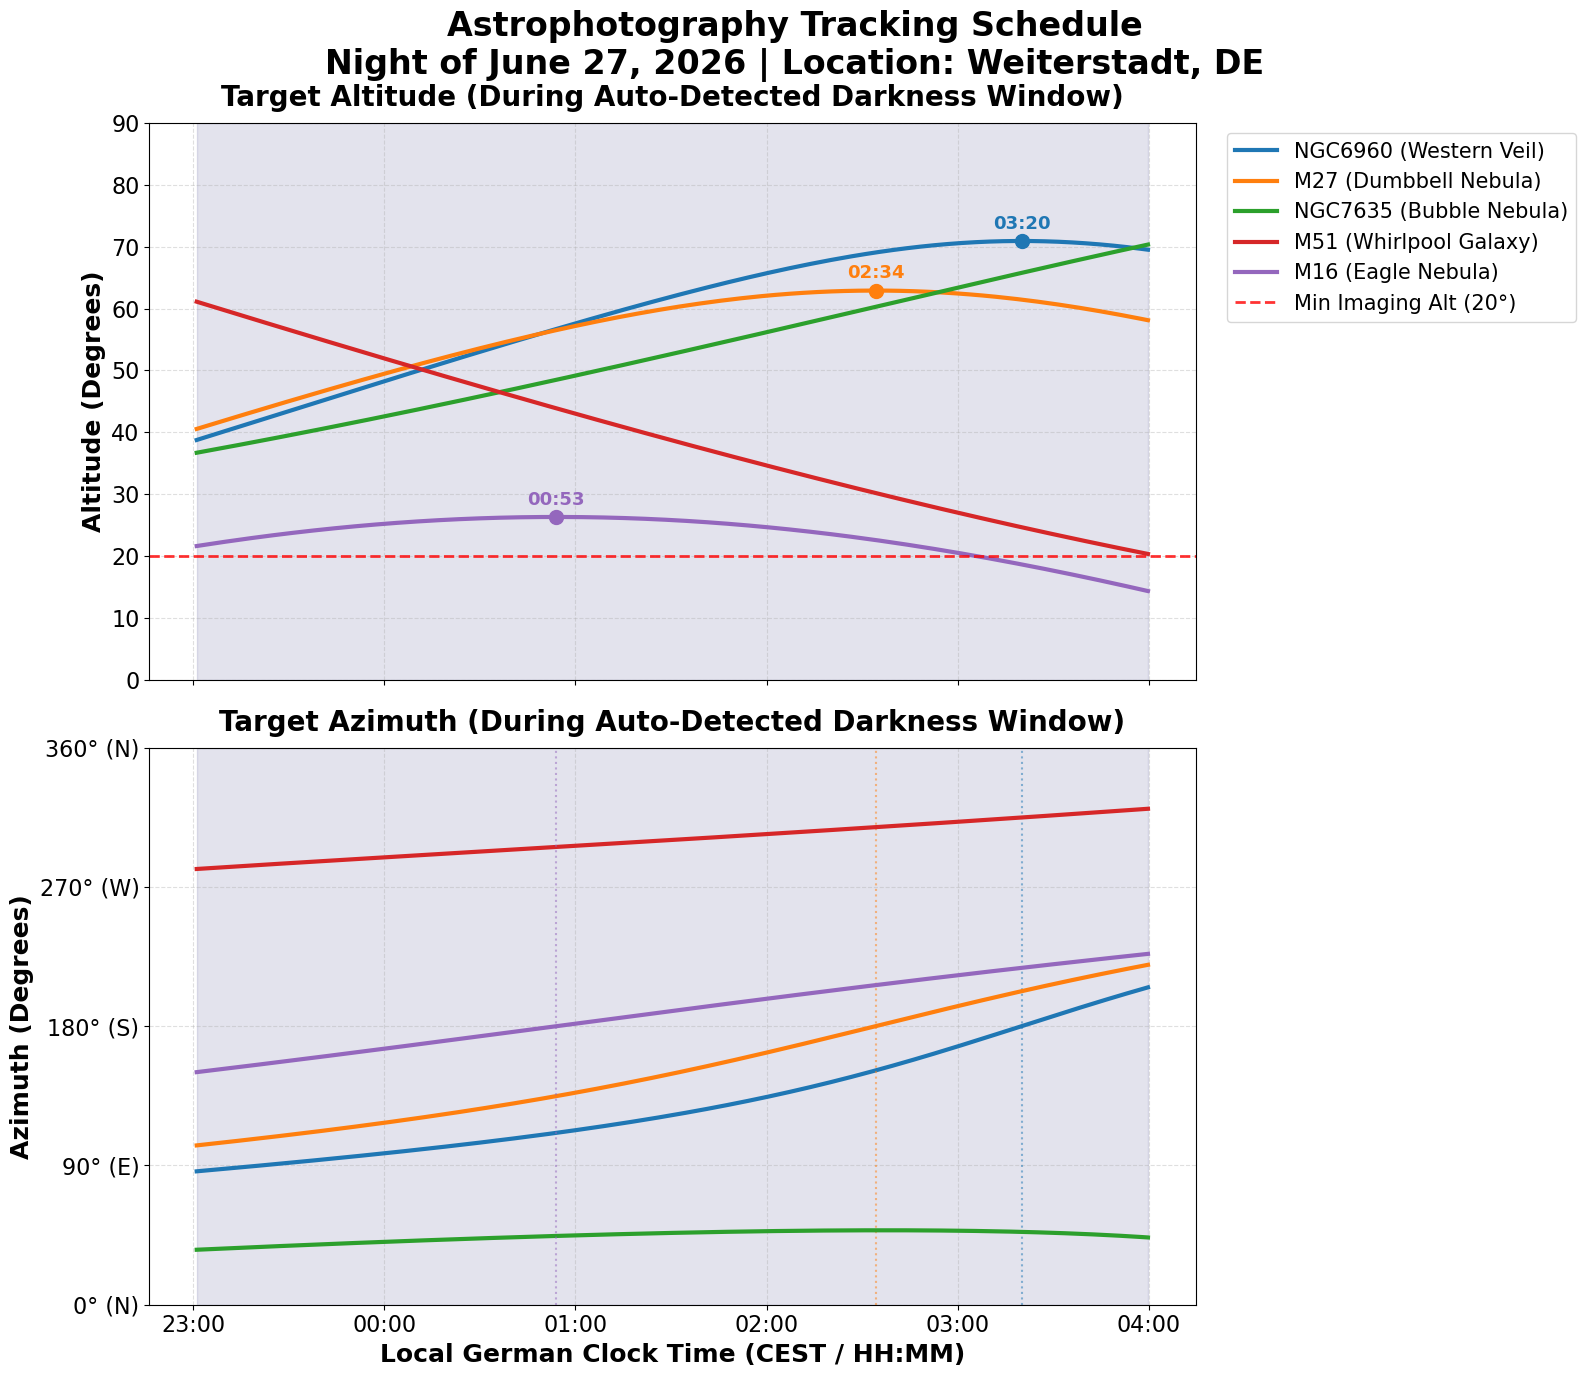

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import EarthLocation, get_sun
from astroplan import Observer, FixedTarget
from geopy.geocoders import Nominatim
import datetime
import zoneinfo
import warnings
from astroplan import TargetAlwaysUpWarning

warnings.filterwarnings("ignore", category=TargetAlwaysUpWarning)



# 1. Define Observation Location
geolocator = Nominatim(user_agent="my_location_app")
location = geolocator.geocode(address)

earth_location = EarthLocation(
    lat=location.latitude * u.deg, 
    lon=location.longitude * u.deg, 
    height=location.altitude * u.m if location.altitude else 0 * u.m
)
observer = Observer(location=earth_location, name="Weiterstadt Home")

# 2. AUTOMATED TIME SCAN (Spans a wide 18-hour window from noon UTC)
scan_start = base_date + 12 * u.hour 
time_grid = scan_start + np.linspace(0, 18, 500) * u.hour

# Calculate Sun position across the grid
sun_altaz = observer.altaz(time_grid, get_sun(time_grid))

# Threshold set to -10° to match the local darkness window from ~23:00 to ~04:00 local time
dark_mask = sun_altaz.alt.deg <= -10.0
dark_times = time_grid[dark_mask]

if len(dark_times) == 0:
    raise ValueError("No matching deep twilight/dark window found for this date.")

# Convert array elements to the German local timezone (Europe/Berlin)
local_tz = zoneinfo.ZoneInfo("Europe/Berlin")
local_datetimes = [dt.replace(tzinfo=datetime.timezone.utc).astimezone(local_tz) for dt in dark_times.datetime.ravel()]

# FIXED: Added [0] index so window_start evaluates as a scalar datetime object, not a full list array
window_start = local_datetimes[0]
window_end = local_datetimes[-1]


# 4. Generate Two Stacked Rows
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

for t in target_list:
    try:
        target = FixedTarget.from_name(t["name"])
        altaz_positions = observer.altaz(dark_times, target)
        
        alts = altaz_positions.alt.deg
        azs = altaz_positions.az.deg
        
        p, = ax1.plot(local_datetimes, alts, label=t["label"], lw=3)
        color = p.get_color()
        ax2.plot(local_datetimes, azs, label=t["label"], lw=3)
        
        # Calculate Meridian Crossing passing a baseline time anchor instance
        transit_time = observer.target_meridian_transit_time(dark_times[0], target, which='next')
        
        # Extract scalar datetime object safely
        transit_dt = transit_time.datetime
        transit_local = transit_dt.replace(tzinfo=datetime.timezone.utc).astimezone(local_tz)
        
        # Check if the transit occurs within our dark window bounds
        if window_start <= transit_local <= window_end:
            transit_alt = observer.altaz(transit_time, target).alt.deg
            if transit_alt > 0:
                ax1.plot(transit_local, transit_alt, marker='o', color=color, markersize=10)
                ax1.text(transit_local, transit_alt + 2, f"{transit_local.strftime('%H:%M')}", 
                         fontsize=13, ha='center', weight='bold', color=color)
                ax2.axvline(transit_local, color=color, linestyle=':', alpha=0.5, lw=1.5)
                
    except Exception as e:
        print(f"Could not process data for {t['name']}: {e}")

# Shade background panels dark safely with scalar endpoints
ax1.axvspan(window_start, window_end, color='midnightblue', alpha=0.12)
ax2.axvspan(window_start, window_end, color='midnightblue', alpha=0.12)

# Format X-Axis for Local Time display explicitly
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=local_tz))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1, tz=local_tz))

# --- Format Panel 1: Altitude ---
ax1.set_title("Target Altitude (During Auto-Detected Darkness Window)", fontsize=20, pad=12, weight='bold')
ax1.set_ylabel("Altitude (Degrees)", fontsize=18, weight='bold')
ax1.set_ylim(0, 90)
ax1.axhline(20, color='red', lw=2, linestyle='--', alpha=0.8, label='Min Imaging Alt (20°)')
ax1.tick_params(axis='both', labelsize=16)
ax1.grid(True, linestyle="--", alpha=0.4)

# --- Format Panel 2: Azimuth ---
ax2.set_title("Target Azimuth (During Auto-Detected Darkness Window)", fontsize=20, pad=12, weight='bold')
ax2.set_xlabel("Local German Clock Time (CEST / HH:MM)", fontsize=18, weight='bold')
ax2.set_ylabel("Azimuth (Degrees)", fontsize=18, weight='bold')
ax2.set_yticks([0, 90, 180, 270, 360])
ax2.set_yticklabels(['0° (N)', '90° (E)', '180° (S)', '270° (W)', '360° (N)'])
ax2.set_ylim(0, 360)
ax2.tick_params(axis='both', labelsize=16)
ax2.grid(True, linestyle="--", alpha=0.4)

# Global configuration text sizing
plt.suptitle(f"Astrophotography Tracking Schedule\nNight of June 27, 2026 | Location: Weiterstadt, DE", fontsize=24, y=0.98, weight='bold')

handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fontsize=15)

plt.tight_layout()
plt.savefig("output/corrected_local_time_night_plot.png", dpi=300, bbox_inches='tight')
plt.show()


Address: Wiesenstrasse 58 64331 Weiterstadt Germany
Detected Timezone String: Europe/Berlin
Active zoneinfo Object: Europe/Berlin


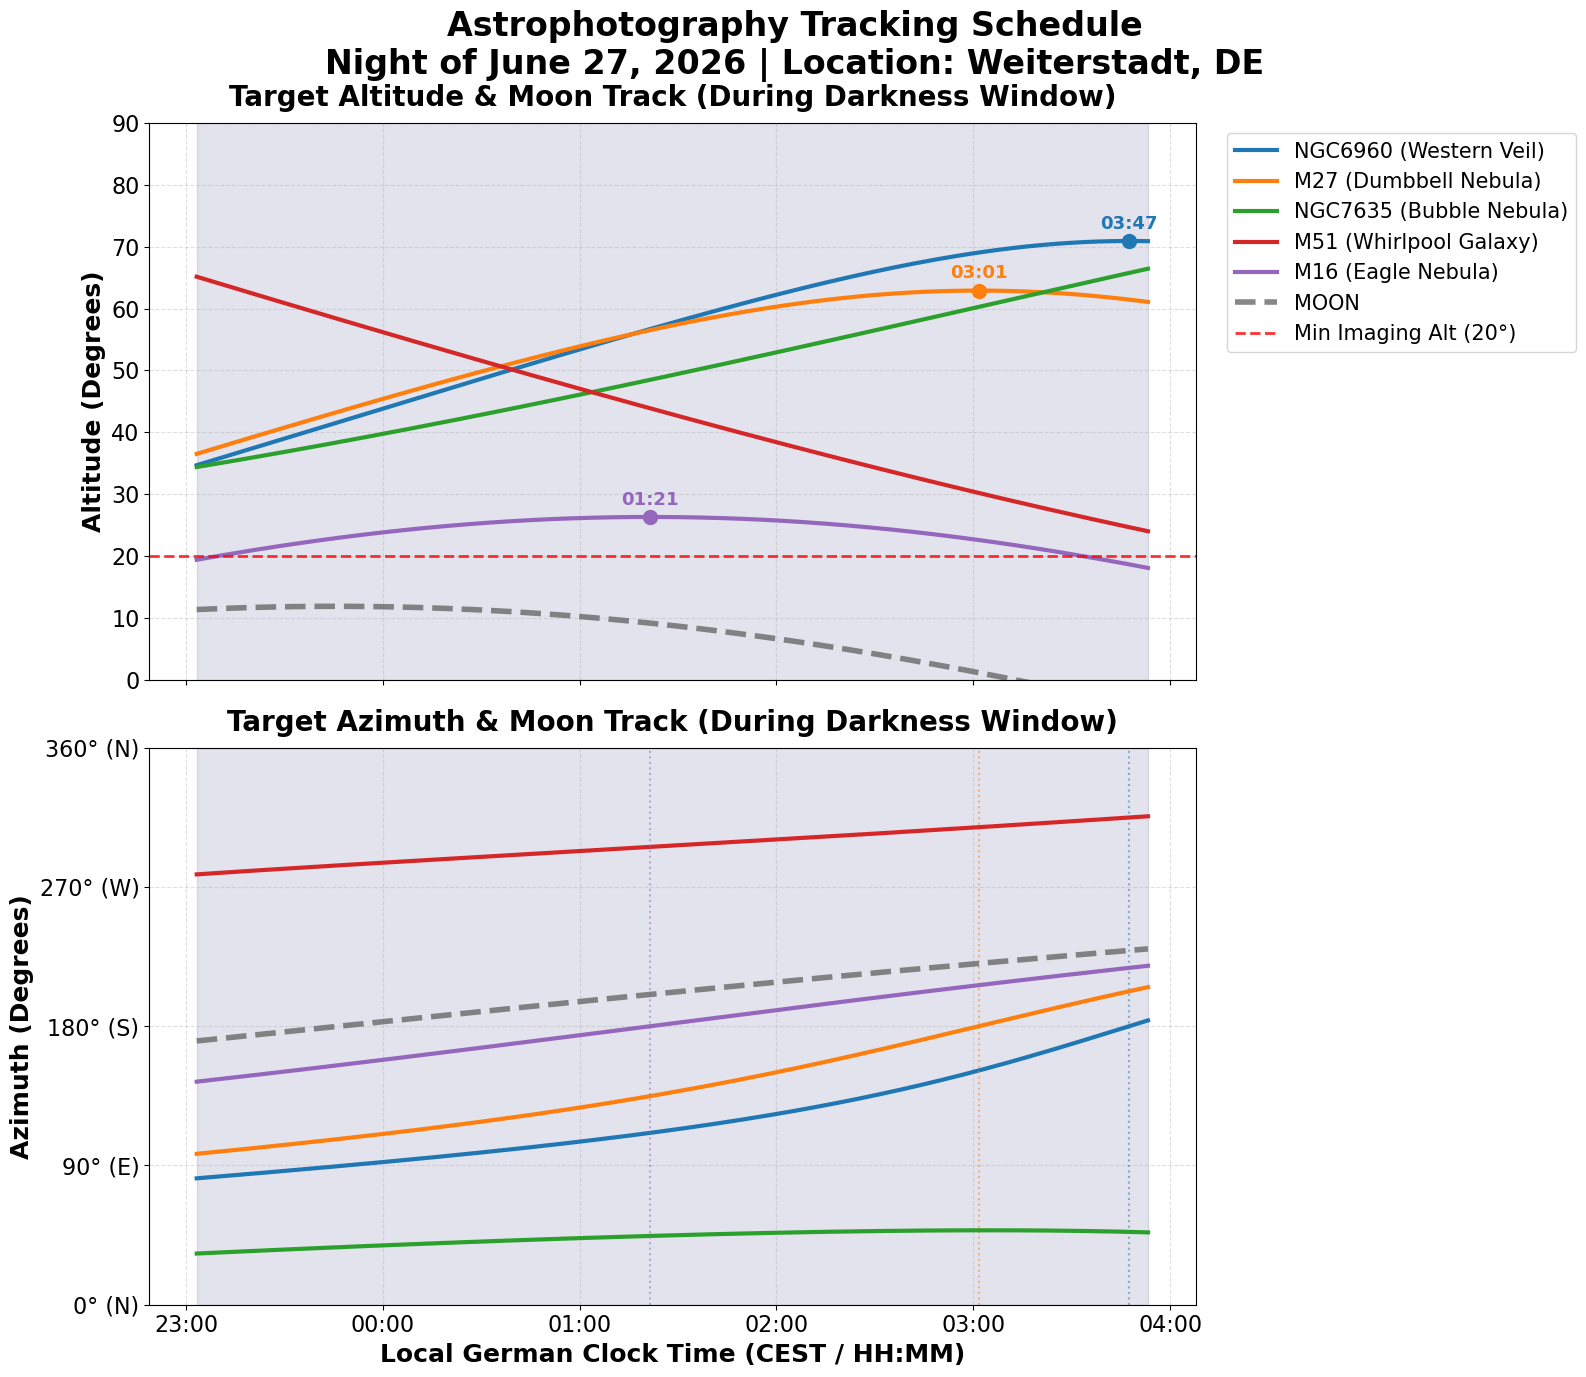

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import EarthLocation, get_sun, get_body
from astroplan import Observer, FixedTarget
from geopy.geocoders import Nominatim
import datetime
import zoneinfo
import warnings
from astroplan import TargetAlwaysUpWarning
from timezonefinder import TimezoneFinder 

warnings.filterwarnings("ignore", category=TargetAlwaysUpWarning)

# 1. Define Observation Location
geolocator = Nominatim(user_agent="my_location_app")
address = "Wiesenstrasse 58 64331 Weiterstadt Germany"
location = geolocator.geocode(address)

earth_location = EarthLocation(
    lat=location.latitude * u.deg, 
    lon=location.longitude * u.deg, 
    height=location.altitude * u.m if location.altitude else 0 * u.m
)
observer = Observer(location=earth_location, name="Weiterstadt Home")

# 2. AUTOMATED TIME SCAN (Spans a wide 18-hour window from noon UTC)
base_date = Time("2026-06-27") 
scan_start = base_date + 12 * u.hour 
time_grid = scan_start + np.linspace(0, 18, 500) * u.hour

# Calculate Sun position across the grid
sun_altaz = observer.altaz(time_grid, get_sun(time_grid))

# Threshold set to -10° to match the local darkness window from ~23:00 to ~04:00 local time
dark_mask = sun_altaz.alt.deg <= -10.0
dark_times = time_grid[dark_mask]

if len(dark_times) == 0:
    raise ValueError("No matching deep twilight/dark window found for this date.")

# Convert array elements to the German local timezone (Europe/Berlin)
#local_tz = zoneinfo.ZoneInfo("Europe/Berlin")

tf = TimezoneFinder()
tz_string = tf.timezone_at(lng=location.longitude, lat=location.latitude)
local_tz = zoneinfo.ZoneInfo(tz_string)

print(f"Address: {address}")
print(f"Detected Timezone String: {tz_string}")  # Prints: Europe/Berlin
print(f"Active zoneinfo Object: {local_tz}")

local_datetimes = [dt.replace(tzinfo=datetime.timezone.utc).astimezone(local_tz) for dt in dark_times.datetime.ravel()]

window_start = local_datetimes[0]
window_end = local_datetimes[-1]


# 4. Generate Two Stacked Rows
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

for t in target_list:
    try:
        target = FixedTarget.from_name(t["name"])
        altaz_positions = observer.altaz(dark_times, target)
        
        alts = altaz_positions.alt.deg
        azs = altaz_positions.az.deg
        
        p, = ax1.plot(local_datetimes, alts, label=t["label"], lw=3)
        color = p.get_color()
        ax2.plot(local_datetimes, azs, label=t["label"], lw=3)
        
        # FIXED: Pass dark_times[0] (a scalar) instead of dark_times (the whole array)
        transit_time = observer.target_meridian_transit_time(dark_times[0], target, which='next')
        
        # Extract scalar datetime object safely
        transit_dt = transit_time.datetime
        transit_local = transit_dt.replace(tzinfo=datetime.timezone.utc).astimezone(local_tz)
        
        # Check if the transit occurs within our dark window bounds
        if window_start <= transit_local <= window_end:
            transit_alt = observer.altaz(transit_time, target).alt.deg
            if transit_alt > 0:
                ax1.plot(transit_local, transit_alt, marker='o', color=color, markersize=10)
                ax1.text(transit_local, transit_alt + 2, f"{transit_local.strftime('%H:%M')}", 
                         fontsize=13, ha='center', weight='bold', color=color)
                ax2.axvline(transit_local, color=color, linestyle=':', alpha=0.5, lw=1.5)
                
    except Exception as e:
        print(f"Could not process data for {t['name']}: {e}")

# --- CALCULATE AND PLOT THE MOON ---
try:
    moon_coords = get_body("moon", dark_times)
    moon_altaz = observer.altaz(dark_times, moon_coords)
    
    moon_alts = moon_altaz.alt.deg
    moon_azs = moon_altaz.az.deg
    
    ax1.plot(local_datetimes, moon_alts, label="MOON", color="dimgray", linestyle="--", lw=4, alpha=0.8)
    ax2.plot(local_datetimes, moon_azs, label="MOON", color="dimgray", linestyle="--", lw=4, alpha=0.8)
except Exception as e:
    print(f"Could not calculate Moon tracking: {e}")

# Shade background panels dark safely with scalar endpoints
ax1.axvspan(window_start, window_end, color='midnightblue', alpha=0.12)
ax2.axvspan(window_start, window_end, color='midnightblue', alpha=0.12)

# Format X-Axis for Local Time display explicitly
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=local_tz))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1, tz=local_tz))

# --- Format Panel 1: Altitude ---
ax1.set_title("Target Altitude & Moon Track (During Darkness Window)", fontsize=20, pad=12, weight='bold')
ax1.set_ylabel("Altitude (Degrees)", fontsize=18, weight='bold')
ax1.set_ylim(0, 90)
ax1.axhline(20, color='red', lw=2, linestyle='--', alpha=0.8, label='Min Imaging Alt (20°)')
ax1.tick_params(axis='both', labelsize=16)
ax1.grid(True, linestyle="--", alpha=0.4)

# --- Format Panel 2: Azimuth ---
ax2.set_title("Target Azimuth & Moon Track (During Darkness Window)", fontsize=20, pad=12, weight='bold')
ax2.set_xlabel("Local German Clock Time (CEST / HH:MM)", fontsize=18, weight='bold')
ax2.set_ylabel("Azimuth (Degrees)", fontsize=18, weight='bold')
ax2.set_yticks([0, 90, 180, 270, 360])
ax2.set_yticklabels(['0° (N)', '90° (E)', '180° (S)', '270° (W)', '360° (N)'])
ax2.set_ylim(0, 360)
ax2.tick_params(axis='both', labelsize=16)
ax2.grid(True, linestyle="--", alpha=0.4)

# Global configuration text sizing
plt.suptitle(f"Astrophotography Tracking Schedule\nNight of June 27, 2026 | Location: Weiterstadt, DE", fontsize=24, y=0.98, weight='bold')

# Group unique labels for the legend to avoid duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fontsize=15)

plt.tight_layout()
plt.savefig("output/corrected_local_time_night_plot.png", dpi=300, bbox_inches='tight')
plt.show()


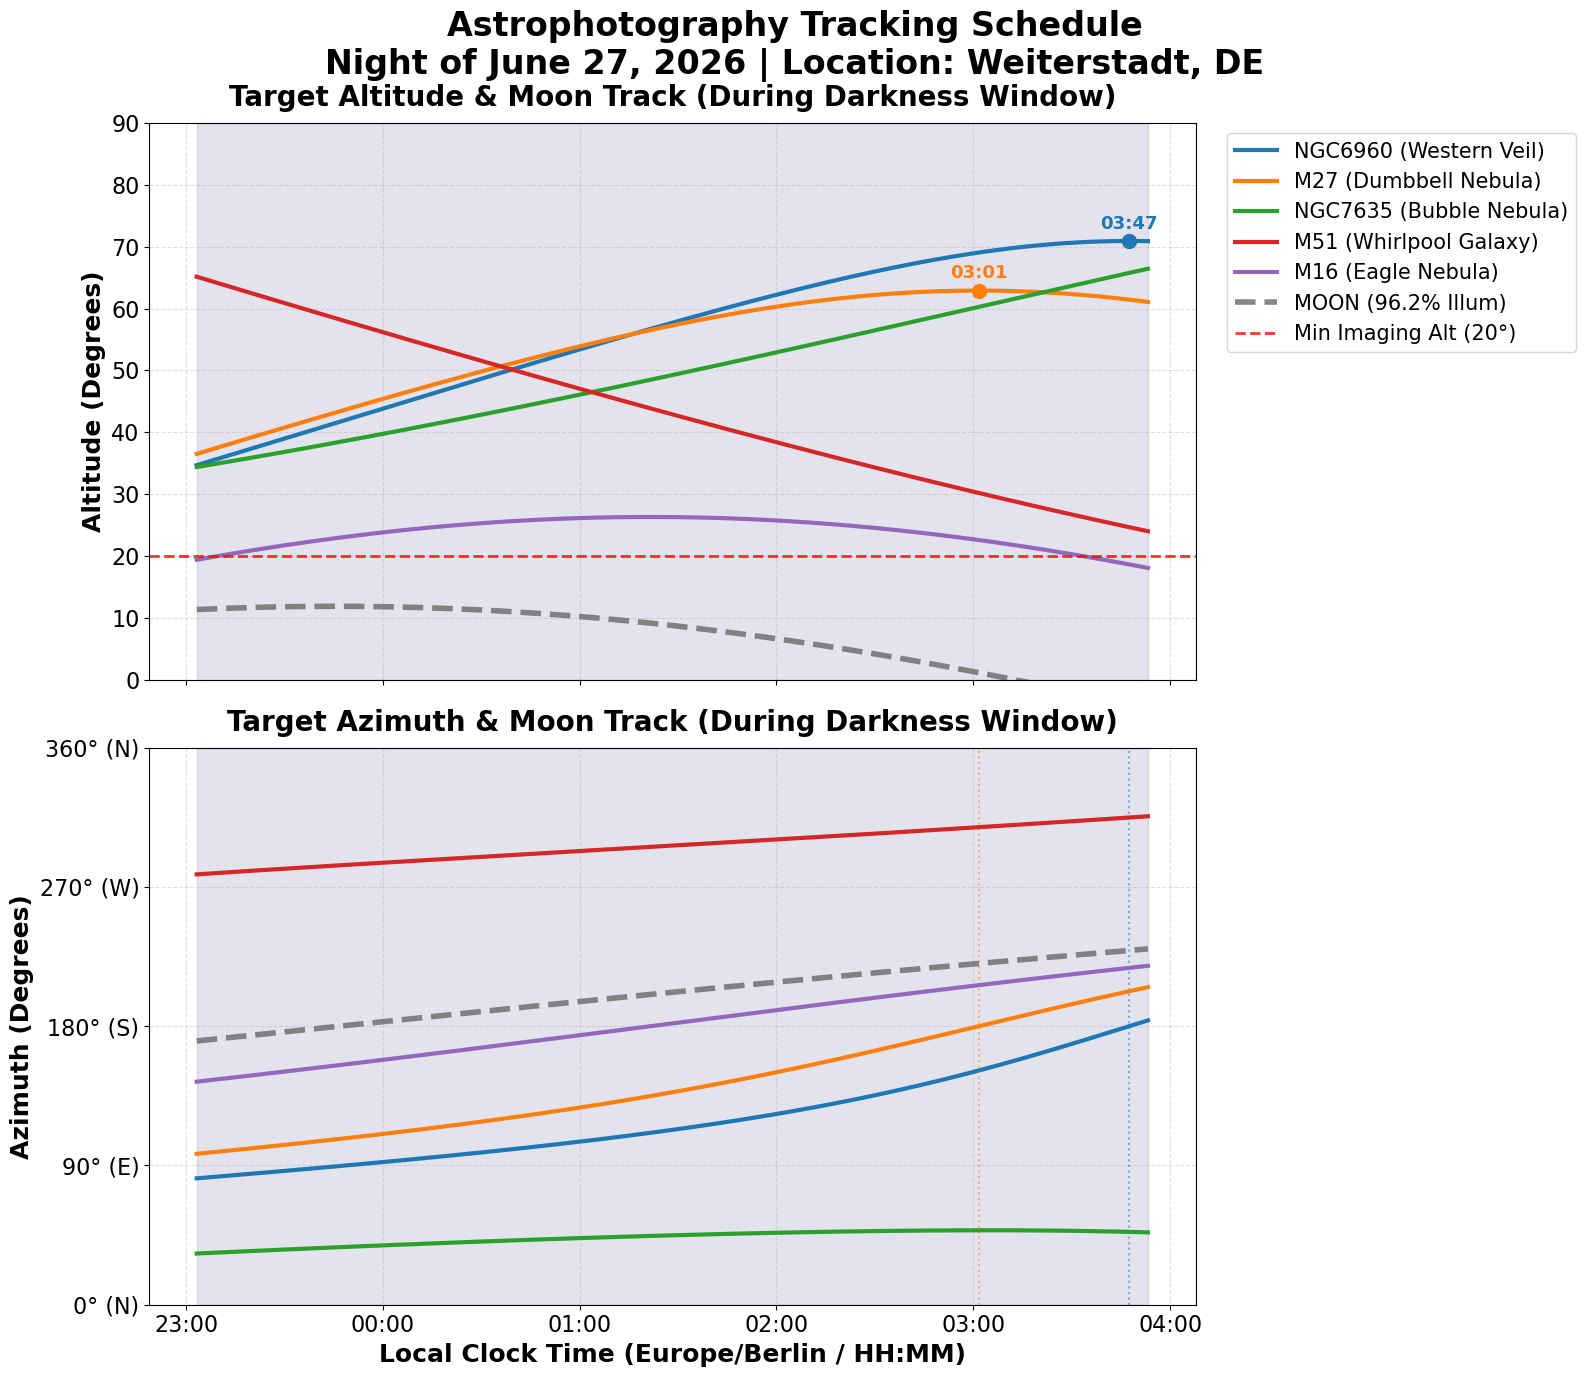

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import EarthLocation, get_sun, get_body
from astroplan import Observer, FixedTarget, moon_illumination
from geopy.geocoders import Nominatim
from timezonefinder import TimezoneFinder
import datetime
import zoneinfo
import warnings
from astroplan import TargetAlwaysUpWarning

warnings.filterwarnings("ignore", category=TargetAlwaysUpWarning)

# 1. Define Observation Location & Extract Timezone Automatically
geolocator = Nominatim(user_agent="my_location_app")
address = "Wiesenstrasse 58 64331 Weiterstadt Germany"
location = geolocator.geocode(address)

earth_location = EarthLocation(
    lat=location.latitude * u.deg, 
    lon=location.longitude * u.deg, 
    height=location.altitude * u.m if location.altitude else 0 * u.m
)
observer = Observer(location=earth_location, name="Weiterstadt Home")

# Fetch timezone dynamically
tf = TimezoneFinder()
tz_string = tf.timezone_at(lng=location.longitude, lat=location.latitude)
local_tz = zoneinfo.ZoneInfo(tz_string)

# 2. AUTOMATED TIME SCAN (Spans a wide 18-hour window from noon UTC)
base_date = Time("2026-06-27") 
scan_start = base_date + 12 * u.hour 
time_grid = scan_start + np.linspace(0, 18, 500) * u.hour

# Calculate Sun position across the grid
sun_altaz = observer.altaz(time_grid, get_sun(time_grid))

# Threshold set to -10° to match the local darkness window from ~23:00 to ~04:00 local time
dark_mask = sun_altaz.alt.deg <= -10.0
dark_times = time_grid[dark_mask]

if len(dark_times) == 0:
    raise ValueError("No matching deep twilight/dark window found for this date.")

# Convert array elements to the local timezone cleanly
local_datetimes = [dt.replace(tzinfo=datetime.timezone.utc).astimezone(local_tz) for dt in dark_times.datetime.ravel()]

# Define the exact start and end scalars of your dark night
window_start = local_datetimes[0]
window_end = local_datetimes[-1]


# 4. Generate Two Stacked Rows
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14), sharex=True)

# Midpoint of the night to use as a single reference time anchor
midpoint_time = dark_times[len(dark_times) // 2]

for t in target_list:
    try:
        target = FixedTarget.from_name(t["name"])
        altaz_positions = observer.altaz(dark_times, target)
        
        alts = altaz_positions.alt.deg
        azs = altaz_positions.az.deg
        
        p, = ax1.plot(local_datetimes, alts, label=t["label"], lw=3)
        color = p.get_color()
        ax2.plot(local_datetimes, azs, label=t["label"], lw=3)
        
        # FIXED: Pass the scalar 'midpoint_time' instead of the array 'dark_times'
        transit_time = observer.target_meridian_transit_time(midpoint_time, target, which='next')
        
        # Extract scalar datetime object safely and convert to local timezone
        transit_dt = transit_time.datetime
        transit_local = transit_dt.replace(tzinfo=datetime.timezone.utc).astimezone(local_tz)
        
        # Check if the transit occurs within our dark window bounds
        if window_start <= transit_local <= window_end:
            transit_alt = observer.altaz(transit_time, target).alt.deg
            if transit_alt > 0:
                ax1.plot(transit_local, transit_alt, marker='o', color=color, markersize=10)
                ax1.text(transit_local, transit_alt + 2, f"{transit_local.strftime('%H:%M')}", 
                         fontsize=13, ha='center', weight='bold', color=color)
                ax2.axvline(transit_local, color=color, linestyle=':', alpha=0.5, lw=1.5)
                
    except Exception as e:
        print(f"Could not process data for {t['name']}: {e}")

# --- CALCULATE MOON POSITION & PHASE ILLUMINATION ---
try:
    moon_coords = get_body("moon", dark_times)
    moon_altaz = observer.altaz(dark_times, moon_coords)
    
    moon_alts = moon_altaz.alt.deg
    moon_azs = moon_altaz.az.deg
    
    # Extract illumination percentage at the midpoint of your tracking session
    moon_phase_percent = moon_illumination(midpoint_time) * 100
    moon_label = f"MOON ({moon_phase_percent:.1f}% Illum)"
    
    ax1.plot(local_datetimes, moon_alts, label=moon_label, color="dimgray", linestyle="--", lw=4, alpha=0.8)
    ax2.plot(local_datetimes, moon_azs, label=moon_label, color="dimgray", linestyle="--", lw=4, alpha=0.8)
except Exception as e:
    print(f"Could not calculate Moon tracking: {e}")

# Shade background panels dark safely with scalar endpoints
ax1.axvspan(window_start, window_end, color='midnightblue', alpha=0.12)
ax2.axvspan(window_start, window_end, color='midnightblue', alpha=0.12)

# Format X-Axis for Local Time display explicitly
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=local_tz))
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1, tz=local_tz))

# --- Format Panel 1: Altitude ---
ax1.set_title("Target Altitude & Moon Track (During Darkness Window)", fontsize=20, pad=12, weight='bold')
ax1.set_ylabel("Altitude (Degrees)", fontsize=18, weight='bold')
ax1.set_ylim(0, 90)
ax1.axhline(20, color='red', lw=2, linestyle='--', alpha=0.8, label='Min Imaging Alt (20°)')
ax1.tick_params(axis='both', labelsize=16)
ax1.grid(True, linestyle="--", alpha=0.4)

# --- Format Panel 2: Azimuth ---
ax2.set_title("Target Azimuth & Moon Track (During Darkness Window)", fontsize=20, pad=12, weight='bold')
ax2.set_xlabel(f"Local Clock Time ({tz_string} / HH:MM)", fontsize=18, weight='bold')
ax2.set_ylabel("Azimuth (Degrees)", fontsize=18, weight='bold')
ax2.set_yticks([0, 90, 180, 270, 360])
ax2.set_yticklabels(['0° (N)', '90° (E)', '180° (S)', '270° (W)', '360° (N)'])
ax2.set_ylim(0, 360)
ax2.tick_params(axis='both', labelsize=16)
ax2.grid(True, linestyle="--", alpha=0.4)

# Global configuration text sizing
plt.suptitle(f"Astrophotography Tracking Schedule\nNight of June 27, 2026 | Location: Weiterstadt, DE", fontsize=24, y=0.98, weight='bold')

# Group unique labels for the legend to avoid duplicates
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, fontsize=15)

plt.tight_layout()
plt.savefig("output/auto_darkness_with_moon_phase.png", dpi=300, bbox_inches='tight')
plt.show()
